1.	Объединить позитивный и негативный корпуса RuTweetCorp, например, используя pd.concat(…).

In [1]:
!pip install gensim

In [2]:
!pip install --upgrade numpy gensim

  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)


In [3]:
!pip install pymorphy3

In [4]:
!pip install fasttext

In [5]:
!pip install --upgrade pip
!pip install --upgrade numpy pandas scipy scikit-learn gensim torch

  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached scipy-1.15.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import nltk
import nltk.corpus
from nltk.corpus import stopwords
import nltk.tokenize
from nltk.stem import WordNetLemmatizer
import string
import gensim
from string import punctuation
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report
import torch.utils.data as data_utils
from sklearn.metrics import classification_report

from nltk.tokenize import word_tokenize
from pymorphy3 import MorphAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

from pymystem3 import Mystem
import chardet
import re
import joblib
from tqdm import tqdm

import torch.optim as optim
from gensim.models import Word2Vec
from gensim.models import FastText
import fasttext

In [7]:
tqdm.pandas()

In [8]:
nltk.download('stopwords')
nltk.download('punkt_tab')
russian_stop_words = set(stopwords.words('russian'))
morph = MorphAnalyzer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [9]:
path_to_raw_data = '/content/'  # Путь к файлам
path_to_datasets = 'datasets/'
negative_file = path_to_raw_data + 'negative.csv'
positive_file = path_to_raw_data + 'positive.csv'
words_all_full_rating = path_to_raw_data + 'words_all_full_rating.csv'

In [10]:
with open(words_all_full_rating, 'rb') as f:
    result = chardet.detect(f.read(10000))
    encoding = result['encoding']

In [11]:
negative_df = pd.read_csv(negative_file, delimiter=";",header=None, names=["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'])
positive_df = pd.read_csv(positive_file, delimiter=";",header=None, names=["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'])

In [12]:
dataset = pd.concat([negative_df, positive_df])

In [13]:
dataset = dataset[:1000]

In [14]:
sentiment=dataset.loc[:,['ttext', 'ttype']]
sentiment.loc[(dataset.ttype < 0), ('ttype')] = 0
sentiment

,ttext,ttype
0,на работе был полный пиддес :| и так каждое за...,0
1,"Коллеги сидят рубятся в Urban terror, а я из-з...",0
2,@elina_4post как говорят обещаного три года жд...,0
3,"Желаю хорошего полёта и удачной посадки,я буду...",0
4,"Обновил за каким-то лешим surf, теперь не рабо...",0
...,...,...
995,Блин спать не дают:( я жесть как спать хочу:(,0
996,"Наткнулась на бабу,с которой в 11 классе на ку...",0
997,"Как оказалось,поменялся для нее,изменился.Но у...",0
998,"А мы опять будем писать ...сочинение ...""как я...",0


In [15]:
X=sentiment['ttext'].values.tolist()
y=sentiment['ttype'].values.tolist()

In [16]:
tokens = [token.lower() for token in dataset['ttext']]
tokens = [re.sub('[^ЙйёЁА-Яа-я0-9 ]', '', token) for token in tokens]
tokens = [re.sub('\s+', ' ', token).strip() for token in tokens]
tokens = [word_tokenize(text.lower(), language='russian') for text in tokens]
tokens = [[word for word in token if word.isalpha() and word not in russian_stop_words] for token in tokens]
tokens = [[morph.parse(word)[0].normal_form for word in filtered_token] for filtered_token in tokens]
X_token = [' '.join(token) for token in tokens]

In [17]:
dataset['norm'] = X_token

# Сохранение в новый файл
dataset.to_csv('/content/dataset_with_norm.csv', index=False)

In [18]:
print("До предобработки:         " + X[0])
print("После предобработки:      " + X_token[0])

До предобработки:         на работе был полный пиддес :| и так каждое закрытие месяца, я же свихнусь так D:
После предобработки:      работа полный пиддес каждый закрытие месяц свихнуться


3.	Извлечь лингвистические признаки, используя тональный словарь LinisCrowd 2015 (http://linis-crowd.org/) по следующему алгоритму:
 1) токенизация;
 2) лемматизация;
 3) определение токенов (после лемматизации) в сообщениях, которые есть в тональном словаре и формирование списка средних значений тональности таких слов.

LinisCrowd

In [19]:
tonal_dict = pd.read_csv(words_all_full_rating, encoding=encoding, sep=';', decimal=',', header=0, usecols=[0,1,2,3])

In [20]:
tonal_dict['Words'] = tonal_dict['Words'].str.lower()

In [21]:
mean_score = []
max_score = []
min_score = []
sum_score = []
positive_count = []
negative_count = []

lemmas = [sentens.split() for sentens in X_token]
for text in lemmas:
    scores = []
    for lemma in text:
        if lemma in tonal_dict['Words'].values:
            score = tonal_dict.loc[tonal_dict['Words'] == lemma, 'mean'].values[0]
            scores.append(score)

    if not scores:
        scores = [0]

    mean_score.append(sum(scores) / len(scores))
    max_score.append(max(scores))
    min_score.append(min(scores))
    sum_score.append(sum(scores))
    positive_count.append(sum(1 for s in scores if s > 0))
    negative_count.append(sum(1 for s in scores if s < 0))

linis_crowd_dataset = pd.DataFrame()

linis_crowd_dataset['mean_std'] = mean_score
linis_crowd_dataset['max_std'] = max_score
linis_crowd_dataset['min_std'] = min_score
linis_crowd_dataset['sum_std'] = sum_score
linis_crowd_dataset['positive_count_std'] = positive_count
linis_crowd_dataset['negative_count_std'] = negative_count

In [22]:
linis_crowd_dataset.to_csv('/content/linis_crowd_dataset.csv', index=False)

# Сохранение в pickle файл
linis_crowd_dataset.to_pickle('/content/linis_crowd_dataset.pkl')

In [23]:
print(linis_crowd_dataset)

     mean_std   max_std   min_std   sum_std  positive_count_std  \
0    0.129630  0.222222  0.000000  0.388889                   2   
1   -0.200000 -0.200000 -0.200000 -0.200000                   0   
2    0.000000  0.000000  0.000000  0.000000                   0   
3    1.111111  1.222222  1.000000  2.222222                   2   
4    0.000000  0.000000  0.000000  0.000000                   0   
..        ...       ...       ...       ...                 ...   
995 -0.166667  0.000000 -0.333333 -0.333333                   0   
996 -0.083333  0.000000 -0.166667 -0.166667                   0   
997 -1.833333 -1.833333 -1.833333 -1.833333                   0   
998 -0.041667  0.250000 -0.333333 -0.083333                   1   
999 -1.500000 -1.500000 -1.500000 -1.500000                   0   

     negative_count_std  
0                     0  
1                     1  
2                     0  
3                     0  
4                     0  
..                  ...  
995          

Вычисление частоты основных частей речи

In [24]:
def extract_pos_frequencies(text, morph):
    words = text
    pos_counts = {}

    for word in words:
        parsed = morph.parse(word)[0]
        pos = parsed.tag.POS
        if pos:
            pos_counts[pos] = pos_counts.get(pos, 0) + 1

    total_words = len(words)
    pos_frequencies = {pos: count / total_words for pos, count in pos_counts.items()}
    return pos_frequencies

results = []
for message in X_token:
    pos_frequencies = extract_pos_frequencies(message, morph)
    results.append(pos_frequencies)


pos_frequencies_dataset = pd.DataFrame(results)
pos_frequencies_dataset = pos_frequencies_dataset.fillna(0)

In [25]:
!pip install dill

In [26]:
import os
import dill

# Путь к папке, где будет сохранён файл
path_to_datasets = 'datasets/'

# Создаем папку, если её нет
os.makedirs(path_to_datasets, exist_ok=True)

# Сохраняем объект в файл
with open(path_to_datasets + 'pos_frequencies_dataset.pkl', 'wb') as f:
    dill.dump(pos_frequencies_dataset, f)

In [27]:
pos_frequencies_dataset.to_csv(path_to_datasets + 'pos_frequencies_dataset.csv', index=False)

In [28]:
print(pos_frequencies_dataset)

         NOUN      CONJ      PRCL      PREP      ADVB      VERB      NPRO  \
0    0.207547  0.132075  0.037736  0.188679  0.113208  0.056604  0.037736   
1    0.177778  0.133333  0.044444  0.177778  0.133333  0.044444  0.022222   
2    0.148148  0.111111  0.074074  0.222222  0.148148  0.037037  0.000000   
3    0.238095  0.111111  0.031746  0.206349  0.095238  0.031746  0.015873   
4    0.250000  0.136364  0.045455  0.204545  0.113636  0.068182  0.000000   
..        ...       ...       ...       ...       ...       ...       ...   
995  0.111111  0.138889  0.055556  0.138889  0.194444  0.055556  0.000000   
996  0.238532  0.165138  0.027523  0.247706  0.082569  0.027523  0.027523   
997  0.228571  0.133333  0.009524  0.209524  0.095238  0.085714  0.038095   
998  0.255319  0.106383  0.021277  0.170213  0.106383  0.127660  0.021277   
999  0.166667  0.041667  0.083333  0.208333  0.166667  0.083333  0.000000   

         INTJ  
0    0.000000  
1    0.000000  
2    0.000000  
3    0.0000

TF-IDF

In [29]:
vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(X_token)

svd = TruncatedSVD(n_components=1000, random_state=42)
reduced_features = svd.fit_transform(tfidf_matrix)

tfidf_dataset = pd.DataFrame(reduced_features)

In [30]:
tfidf_dataset.to_csv(path_to_datasets + 'tfidf_dataset.csv', index=False)
joblib.dump(tfidf_dataset, path_to_datasets + "tfidf_dataset.npy")
tfidf_dataset.to_pickle(path_to_datasets + 'tfidf_dataset.pkl')

In [31]:
print(tfidf_dataset)

          0         1         2         3         4         5         6    \
0    0.035294 -0.036179  0.004878 -0.016676 -0.034255  0.026322  0.017346   
1    0.076346 -0.047452  0.213144  0.071013  0.017579 -0.046016  0.052915   
2    0.066481 -0.051705 -0.001025 -0.094841 -0.052219  0.007117  0.103209   
3    0.088837 -0.076606  0.036229 -0.092541 -0.005314 -0.073946 -0.003442   
4    0.005787 -0.006528  0.006170  0.001723 -0.003322  0.025556  0.002085   
..        ...       ...       ...       ...       ...       ...       ...   
995  0.317430  0.148437  0.072725 -0.163359 -0.061619  0.062669 -0.346086   
996  0.014531 -0.006945  0.006999 -0.008653 -0.003976  0.004200  0.012387   
997  0.109608 -0.115443 -0.096023  0.096088 -0.027849 -0.059224 -0.011666   
998  0.067537 -0.047729 -0.012930 -0.026105 -0.045636 -0.038814 -0.031463   
999  0.030003 -0.016652 -0.015612 -0.000471 -0.004151  0.002530 -0.016034   

          7         8         9    ...           990           991  \
0    

My Word2Vec

In [32]:
df = pd.read_csv(path_to_datasets + 'dataset_with_norm.csv')

In [33]:
dataset = dataset[:1000]

In [34]:
df = df.loc[:,['norm', 'ttype']]
df.loc[(df.ttype < 0), ('ttype')] = 0
df

,norm,ttype
0,работа полный пиддес каждый закрытие месяц сви...,0
1,коллега сидеть рубиться изз долбать винд мочь,0
2,говорить обещаной год ждать,0
3,желать хороший полёт удачный посадкия быть оче...,0
4,обновить какимтый леший работать простоплеер,0
...,...,...
995,блин спать давать жесть спать хотеть,0
996,наткнуться бабусы который класс курс ходилау н...,0
997,оказалосьпоменяться нееизменилсяный увыизменит...,0
998,быть писать сочинение провести лето четыре язык,0


In [35]:
lemmas = [str(sentense).split() for sentense in df['norm']]
df['tokens'] = lemmas

In [36]:
model_word2vec = Word2Vec(sentences=lemmas, vector_size=100, window=15)

In [37]:
model_word2vec.train(lemmas, total_examples=model_word2vec.corpus_count, epochs=10)

(13954, 61830)

In [38]:
path_to_models = 'model/'

# Создаем папку, если её нет
os.makedirs(path_to_models, exist_ok=True)

# Сохраняем модель
joblib.dump(model_word2vec, path_to_models + 'model_word2vec.pkl')

['model/model_word2vec.pkl']

In [39]:
def get_w2v_vector(tokens, model, vector_size=100):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)


df['w2v_features'] = df['tokens'].apply(lambda x: get_w2v_vector(x, model_word2vec))

In [40]:
df['w2v_features']

,w2v_features
0,"[-0.0072568553, 0.004169001, -0.00984643, 0.00..."
1,"[-0.0062556933, 0.0066271834, -0.0093353735, 0..."
2,"[-0.011320279, 0.009064793, 0.00096597435, 0.0..."
3,"[-0.0024403934, 0.009750475, -0.0034355903, 0...."
4,"[7.774379e-05, 0.011928424, 0.0029542807, -0.0..."
...,...
995,"[-0.010552913, 0.0065816133, -0.0021189942, 0...."
996,"[-0.01307281, 0.0036989476, 0.0012381373, 0.00..."
997,"[-0.012012531, 0.01356128, -0.00252034, 0.0068..."
998,"[-0.0075646234, 0.0066319196, 0.002668283, 0.0..."


In [41]:
model_word2vec.wv.most_similar('работа')

[('хотеть', 0.9192790985107422),
 ('сегодня', 0.9004130363464355),
 ('смотреть', 0.8957512974739075),
 ('мочь', 0.8880608677864075),
 ('быть', 0.8847151398658752),
 ('это', 0.8831404447555542),
 ('час', 0.8818054795265198),
 ('пойти', 0.879618227481842),
 ('завтра', 0.8792706727981567),
 ('блин', 0.8774706125259399)]

Word2Vec from binares

In [42]:
path_to_model = "/content/model/model.bin"
print(f"Размер файла: {os.path.getsize(path_to_model)} байт")

Размер файла: 231349895 байт


In [43]:
w2v_model_loaded = gensim.models.KeyedVectors.load_word2vec_format("/content/model/model.bin", binary=True)
w2v_model_loaded.init_sims(replace=True)

<ipython-input-43-9e639428e6bd>:2: DeprecationWarning: Call to deprecated `init_sims` (Use fill_norms() instead. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  w2v_model_loaded.init_sims(replace=True)


In [44]:
keys = list(w2v_model_loaded.key_to_index.keys())
values = [i.split('_')[0] for i in keys]
indexes = dict(zip(values, keys))

def get_index(word, indexes=indexes):
    word = str(word).lower()
    return indexes.get(word, 'NONE')

In [45]:
get_index('Привет')

'привет_PROPN'

In [46]:
get_index('Кот')

'кот_PROPN'

In [47]:
get_index('Работа')

'работа_ADJ'

In [48]:
# def get_w2v_vector2(tokens, model, vector_size=100):
#     vectors = [model.get_vector(get_index(word)) for word in tokens if get_index(word) != 'NONE']
#     return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)
#
# df['word_to_vec_loaded'] = df['tokens'].progress_apply(lambda x: get_w2v_vector2(x, w2v_model_loaded))

In [49]:
def get_w2v_vector2(tokens, model, vector_size=100):
    vectors = []
    for word in tokens:
        try:
            vector = model.get_vector(word)
            vectors.append(vector)
        except KeyError:
            continue

    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size)

df['word_to_vec_loaded'] = df['tokens'].progress_apply(lambda x: get_w2v_vector2(x, w2v_model_loaded, vector_size=100))

lengths = df['word_to_vec_loaded'].apply(len)
print(lengths.value_counts())  # Должно быть одно значение (100)

100%|██████████| 1000/1000 [00:00<00:00, 89842.65it/s]

word_to_vec_loaded
100    1000
Name: count, dtype: int64


In [50]:
df['word_to_vec_loaded']

,word_to_vec_loaded
0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...
995,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
996,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
997,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
998,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [51]:
w2v_model_loaded[w2v_model_loaded.key_to_index['работа_NOUN']]

array([-5.85179999e-02,  1.51592894e-02,  5.26082925e-02,  2.84647346e-02,
       -9.19876322e-02,  3.31219174e-02, -5.48914485e-02,  8.50201547e-02,
       -4.79608141e-02, -4.56790999e-02, -9.79803130e-03, -2.82755475e-02,
        2.62311511e-02,  4.88116108e-02, -9.27252602e-03,  3.13171744e-02,
        1.15742274e-01, -1.07745007e-02,  1.34846484e-02,  2.54330169e-02,
       -1.21560041e-02, -5.74568734e-02, -4.39964607e-02, -2.54943911e-02,
       -2.92804721e-03, -5.36553748e-03,  5.58856130e-03, -7.76704550e-02,
       -7.14043528e-02, -3.60808447e-02, -3.80626358e-02, -2.96954205e-03,
       -4.11674334e-03,  2.94200815e-02, -2.26382669e-02,  4.57425900e-02,
        8.05843994e-02, -6.46375716e-02,  4.37328219e-03, -3.19926478e-02,
        6.68301806e-02, -6.37132525e-02, -2.53209062e-02,  2.30549518e-02,
        6.25994205e-02,  6.14756420e-02,  2.49930043e-02, -1.55610614e-04,
        9.81186703e-02,  2.21989341e-02,  6.33945614e-02,  4.56209742e-02,
        6.32128539e-03,  

In [52]:
w2v_model_loaded.key_to_index['работа_NOUN']

51

In [53]:
w2v_model_loaded.similarity('кошка_NOUN', 'собака_NOUN')

0.68299186

In [54]:
w2v_model_loaded.similarity('кошка_NOUN', 'день_NOUN')

-0.028457804

In [55]:
w2v_model_loaded.most_similar(positive=['париж_NOUN','россия_NOUN'], negative=['берлин_NOUN'], topn=1)

[('франция_PROPN', 0.3989067077636719)]

In [56]:
df.to_csv(path_to_datasets + 'word2vec_vectors_dataset.csv', index=False)

My Fast Text

In [57]:
model_fast_text = FastText(sentences=df['tokens'], vector_size=100, window=15, min_count=5, sg=1)

In [58]:
model_fast_text.train(df['tokens'], total_examples=model_word2vec.corpus_count, epochs=10)

(13954, 61830)

In [59]:
model_fast_text.save(path_to_models + "my_fast_text.bin")

In [60]:
model_fast_text.wv.most_similar('работа')

[('работать', 0.9999619722366333),
 ('смотреть', 0.9999297857284546),
 ('посмотреть', 0.9999291896820068),
 ('хотеть', 0.9999240636825562),
 ('суббота', 0.9999215602874756),
 ('купить', 0.9999211430549622),
 ('болеть', 0.9999180436134338),
 ('сказать', 0.9999173879623413),
 ('думать', 0.9999170899391174),
 ('простить', 0.9999164938926697)]

In [61]:
def get_ft_vector(tokens, model, vector_size=100):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)

df['fast_text_features'] = df['tokens'].progress_apply(lambda x: get_ft_vector(x, model_fast_text))
df.to_csv(path_to_datasets + 'my_fast_text.csv', index=False)

100%|██████████| 1000/1000 [00:00<00:00, 2715.44it/s]


Fast Text from binares

In [62]:
from huggingface_hub import hf_hub_download

In [63]:
model_path = hf_hub_download(repo_id="facebook/fasttext-ru-vectors", filename="model.bin")
model = fasttext.load_model(model_path)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [64]:
def get_ft_vector(tokens, model, vector_size=100):
    vectors = [model[word] for word in tokens]
    return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)

df['fast_text_loaded'] = df['tokens'].progress_apply(lambda x: get_ft_vector(x, model))

100%|██████████| 1000/1000 [00:00<00:00, 5749.44it/s]


In [65]:
df['fast_text_loaded']

,fast_text_loaded
0,"[-2.8524015e-05, -0.02114207, 0.014387419, 0.0..."
1,"[0.07968112, -0.028001538, 0.06807278, -0.0625..."
2,"[0.012949028, -0.0373013, -0.008395562, -0.007..."
3,"[0.03786959, -0.0055939797, 0.019714734, 0.021..."
4,"[-0.01707895, -0.008487223, -0.00036525782, 0...."
...,...
995,"[0.03748365, -0.017108614, -0.040648535, -0.00..."
996,"[0.02128529, -0.026280545, -0.007832578, 0.021..."
997,"[0.011729631, -0.03762372, 0.0047421004, 0.015..."
998,"[0.0071233558, -0.016253052, -0.04671108, 0.01..."


In [66]:
df.to_csv(path_to_datasets + 'dataset_with_model_vectors.csv', index=False)

In [67]:
df.head()

,norm,ttype,tokens,w2v_features,word_to_vec_loaded,fast_text_features,fast_text_loaded
0,работа полный пиддес каждый закрытие месяц сви...,0,"[работа, полный, пиддес, каждый, закрытие, мес...","[-0.0072568553, 0.004169001, -0.00984643, 0.00...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.15142055, 0.033803556, -0.026273858, 0.076...","[-2.8524015e-05, -0.02114207, 0.014387419, 0.0..."
1,коллега сидеть рубиться изз долбать винд мочь,0,"[коллега, сидеть, рубиться, изз, долбать, винд...","[-0.0062556933, 0.0066271834, -0.0093353735, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.21060112, 0.047952496, -0.037078675, 0.108...","[0.07968112, -0.028001538, 0.06807278, -0.0625..."
2,говорить обещаной год ждать,0,"[говорить, обещаной, год, ждать]","[-0.011320279, 0.009064793, 0.00096597435, 0.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.2741765, 0.06006755, -0.048208892, 0.14109...","[0.012949028, -0.0373013, -0.008395562, -0.007..."
3,желать хороший полёт удачный посадкия быть оче...,0,"[желать, хороший, полёт, удачный, посадкия, бы...","[-0.0024403934, 0.009750475, -0.0034355903, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.21630932, 0.04912763, -0.03771108, 0.11134...","[0.03786959, -0.0055939797, 0.019714734, 0.021..."
4,обновить какимтый леший работать простоплеер,0,"[обновить, какимтый, леший, работать, простопл...","[7.774379e-05, 0.011928424, 0.0029542807, -0.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.17437078, 0.0398578, -0.03109667, 0.089314...","[-0.01707895, -0.008487223, -0.00036525782, 0...."


# Training

In [68]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
import keras
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import dill

import pandas as pd

In [70]:
tqdm.pandas()
np.set_printoptions(precision=3, suppress=True)

In [89]:
df = pd.read_pickle(path_to_datasets + 'dataset_with_model_vectors.pkl')

In [90]:
df['w2v_features'][0].shape

(100,)

In [91]:
df

,norm,ttype,tokens,w2v_features,word_to_vec_loaded,fast_text_features,fast_text_loaded
0,работа полный пиддес каждый закрытие месяц сви...,0,"[работа, полный, пиддес, каждый, закрытие, мес...","[-0.0072568553, 0.004169001, -0.00984643, 0.00...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.15142055, 0.033803556, -0.026273858, 0.076...","[-2.8524015e-05, -0.02114207, 0.014387419, 0.0..."
1,коллега сидеть рубиться изз долбать винд мочь,0,"[коллега, сидеть, рубиться, изз, долбать, винд...","[-0.0062556933, 0.0066271834, -0.0093353735, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.21060112, 0.047952496, -0.037078675, 0.108...","[0.07968112, -0.028001538, 0.06807278, -0.0625..."
2,говорить обещаной год ждать,0,"[говорить, обещаной, год, ждать]","[-0.011320279, 0.009064793, 0.00096597435, 0.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.2741765, 0.06006755, -0.048208892, 0.14109...","[0.012949028, -0.0373013, -0.008395562, -0.007..."
3,желать хороший полёт удачный посадкия быть оче...,0,"[желать, хороший, полёт, удачный, посадкия, бы...","[-0.0024403934, 0.009750475, -0.0034355903, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.21630932, 0.04912763, -0.03771108, 0.11134...","[0.03786959, -0.0055939797, 0.019714734, 0.021..."
4,обновить какимтый леший работать простоплеер,0,"[обновить, какимтый, леший, работать, простопл...","[7.774379e-05, 0.011928424, 0.0029542807, -0.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.17437078, 0.0398578, -0.03109667, 0.089314...","[-0.01707895, -0.008487223, -0.00036525782, 0...."
...,...,...,...,...,...,...,...
995,блин спать давать жесть спать хотеть,0,"[блин, спать, давать, жесть, спать, хотеть]","[-0.010552913, 0.0065816133, -0.0021189942, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.38689384, 0.08671516, -0.06856959, 0.19827...","[0.03748365, -0.017108614, -0.040648535, -0.00..."
996,наткнуться бабусы который класс курс ходилау н...,0,"[наткнуться, бабусы, который, класс, курс, ход...","[-0.01307281, 0.0036989476, 0.0012381373, 0.00...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.06418084, 0.014413196, -0.010882, 0.032942...","[0.02128529, -0.026280545, -0.007832578, 0.021..."
997,оказалосьпоменяться нееизменилсяный увыизменит...,0,"[оказалосьпоменяться, нееизменилсяный, увыизме...","[-0.012012531, 0.01356128, -0.00252034, 0.0068...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.14937335, 0.03353301, -0.026345026, 0.0779...","[0.011729631, -0.03762372, 0.0047421004, 0.015..."
998,быть писать сочинение провести лето четыре язык,0,"[быть, писать, сочинение, провести, лето, четы...","[-0.0075646234, 0.0066319196, 0.002668283, 0.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.16655973, 0.037215628, -0.028881516, 0.085...","[0.0071233558, -0.016253052, -0.04671108, 0.01..."


Model initialisation

In [74]:
def sentiment_analysis_model(input_shape):
    model = Sequential([
    Dense(128, activation='relu', input_shape=(input_shape,)),  # Входной слой
    Dropout(0.5),  # Dropout для предотвращения переобучения
    Dense(64, activation='relu'),  # Скрытый слой
    Dropout(0.5),  # Еще один Dropout
    Dense(1, activation='sigmoid')
    ])

    return model

In [75]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def sentiment_analysis_model(input_shape):
    model = Sequential([
    Dense(256, activation='relu', input_shape=(input_shape,)),  # Входной слой
    BatchNormalization(),  # Нормализация активаций
    Dropout(0.5),  # Dropout для предотвращения переобучения
    Dense(128, activation='relu'),  # Скрытый слой
    BatchNormalization(),  # Нормализация активаций
    Dropout(0.5),  # Еще один Dropout
    Dense(64, activation='relu'),  # Скрытый слой
    BatchNormalization(),  # Нормализация активаций
    Dropout(0.3),  # Меньший Dropout
    Dense(1, activation='sigmoid')  # Выходной слой (бинарная классификация)
    ])

    return model

In [76]:
def sentiment_analysis_model(input_shape):
    model = Sequential()

    model.add(Input(shape=(input_shape,)))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(1, activation='sigmoid'))

    return model

In [77]:
def save_model(model: tf.keras.Model):
    os.makedirs('saved_models', exist_ok=True)
    os.makedirs('saved_models/' + str(date.today()), exist_ok=True)
    path = 'saved_models/' + str(date.today()) + '/'

    model.save_weights(path + 'weights_speech_intelligibility_assessment' + '.weights.h5')
    model.save(path + 'model_speech_intelligibility_assessment' + '.keras')

In [78]:
def save_history(history):
    os.makedirs('saved_models', exist_ok=True)
    os.makedirs('saved_models/' + str(date.today()), exist_ok=True)
    path = 'saved_models/' + str(date.today()) + '/'
    history_filename = path + 'history_speech_intelligibility_assessment' + '.pkl'
    with open(history_filename, 'wb') as f:
        pickle.dump(history.history, f)

In [79]:
def train_model(dataset, model, learning_rate=0.001, num_classes=1, epochs=10):
    if num_classes == 1:
        loss = 'binary_crossentropy'
        metrics = [
            'accuracy',
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall()
        ]
    else:
        loss = 'categorical_crossentropy'
        metrics = [
            'accuracy',
            tf.keras.metrics.F1Score(average='weighted')  # Для многоклассовой классификации
        ]

    # Компиляция модели
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=loss,
        metrics=metrics
    )

    # Обучение модели
    history = model.fit(
        dataset,
        epochs=epochs,
        verbose=1
    )

    return model, history

In [80]:
def train_and_evaluate_model(X_, y_, epochs=10, batch_size = 32, learning_rate = 0.001):
    y = np.array(y_)
    X = np.array(X_.tolist())

    vocab_size = X.shape[0]
    max_length = X[0].shape[0]
    num_classes = 1

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

    dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    dataset = dataset.shuffle(vocab_size)
    dataset = dataset.batch(batch_size)

    model = sentiment_analysis_model(max_length)
    model, history = train_model(dataset, model, learning_rate=learning_rate, num_classes=num_classes, epochs=epochs)

    y_pred = model.predict(X_test)
    y_pred = np.round(y_pred).astype(int)

    f1 = f1_score(y_test, y_pred)
    print(f'F1 Score: {f1:.4f}')
    model.evaluate(X_test, y_test)
    model.summary()

    conf_matrix = tf.math.confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(2), yticklabels=range(2))
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    return f1

In [81]:
f1_metrics = {}

In [82]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns  # Also ensure seaborn is imported for the heatmap

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 1.0000 - loss: 0.6900 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.6777 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.6655 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.6536 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.6419 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.6304 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.6192 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.6082 - precision: 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.5789 - precision: 0.0000e+00 - recall: 0.0000e+00  


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          12,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 88,901 (347.27 KB)

 Trainable params: 29,633 (115.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 59,268 (231.52 KB)

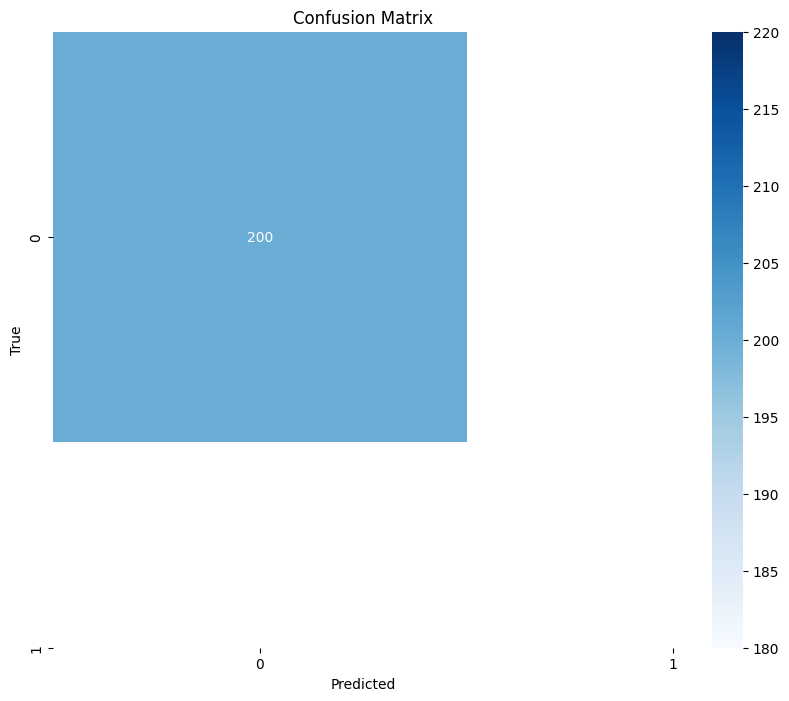

In [83]:
f1_metrics['word_to_vec_loaded'] = train_and_evaluate_model(df['word_to_vec_loaded'], df['ttype'])

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9270 - loss: 0.5354 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0338 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0040 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 4.9369e-04 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 5.0309e-04 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 1.4668e-04 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 6.4466e-05 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - a

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 1.5613e-07 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00  


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 128)                 │          12,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 88,901 (347.27 KB)

 Trainable params: 29,633 (115.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 59,268 (231.52 KB)

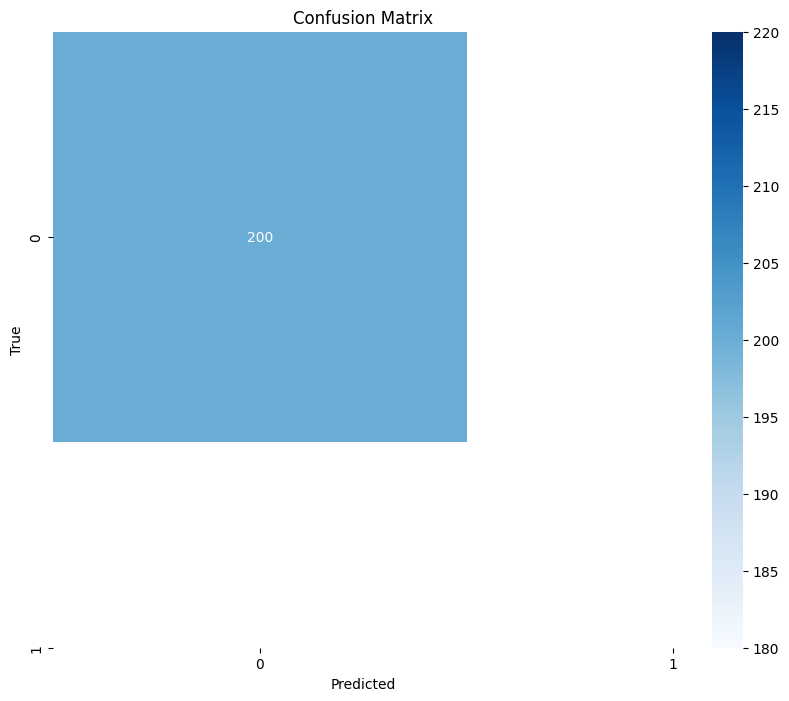

In [84]:
f1_metrics['fast_text_features'] = train_and_evaluate_model(df['fast_text_features'], df['ttype'])

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9722 - loss: 0.5311 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0103 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 2.7010e-04 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 1.3045e-04 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 1.1004e-04 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 1.5339e-04 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 6.6216e-05 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


F1 Score: 0.0000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 7.2020e-06 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00  


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 128)                 │          38,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 165,701 (647.27 KB)

 Trainable params: 55,233 (215.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 110,468 (431.52 KB)

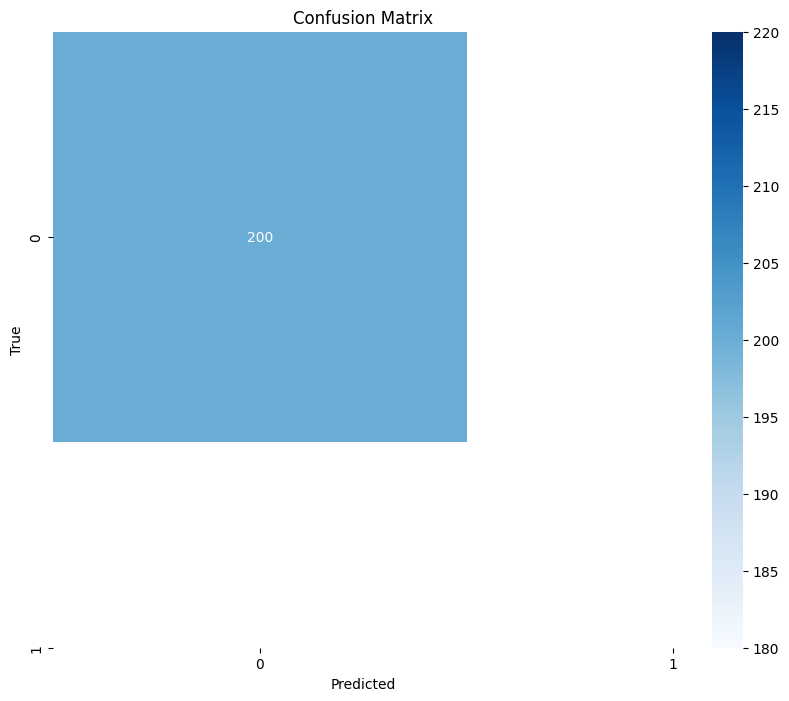

In [85]:
f1_metrics['fast_text_loaded'] = train_and_evaluate_model(df['fast_text_loaded'], df['ttype'])

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9629 - loss: 0.5903 - precision_3: 0.0000e+00 - recall_3: 0.0000e+00
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 1.0000 - loss: 0.0694 - precision_3: 0.0000e+00 - recall_3: 0.0000e+00
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 8.8333e-04 - precision_3: 0.0000e+00 - recall_3: 0.0000e+00
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 1.0000 - loss: 3.8019e-04 - precision_3: 0.0000e+00 - recall_3: 0.0000e+00
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 2.1374e-04 - precision_3: 0.0000e+00 - recall_3: 0.0000e+00
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 1.5413e-04 - precision_3: 0.0000e+00 - recall_3: 0.0000e+00
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 1.2080e-04 - precision_3: 0.0000e+00 - recall_3: 0.0000e+00
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5m

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


F1 Score: 0.0000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 6.3362e-05 - precision_3: 0.0000e+00 - recall_3: 0.0000e+00  


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 128)                 │         128,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 434,501 (1.66 MB)

 Trainable params: 144,833 (565.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 289,668 (1.10 MB)

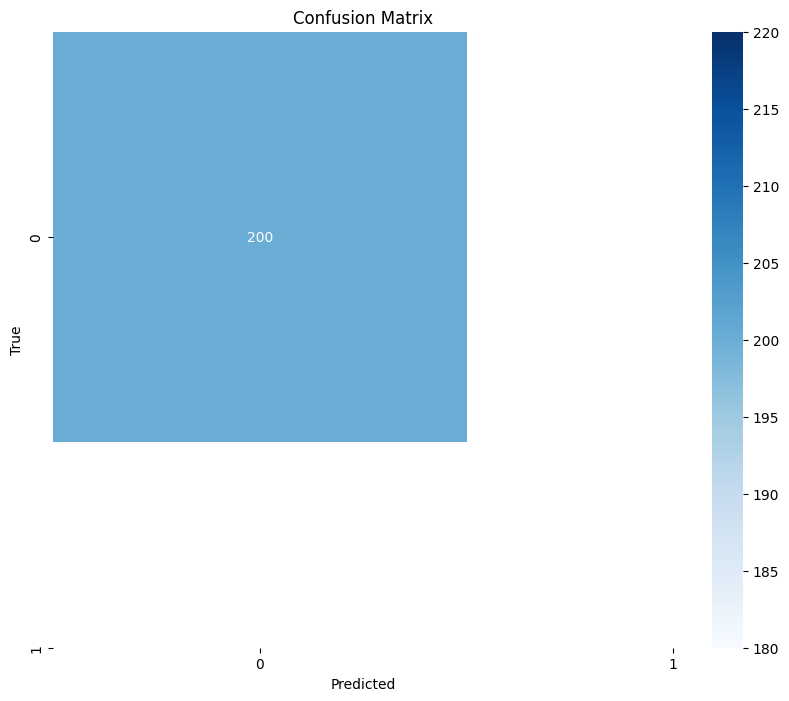

In [92]:
tfidf = np.array(pd.read_pickle(path_to_datasets + 'tfidf_dataset.pkl'))
f1_metrics['tfidf'] = train_and_evaluate_model(tfidf, df['ttype'])

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8873 - loss: 0.5931 - precision_4: 0.0000e+00 - recall_4: 0.0000e+00
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0830 - precision_4: 0.0000e+00 - recall_4: 0.0000e+00
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0011 - precision_4: 0.0000e+00 - recall_4: 0.0000e+00
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 3.4677e-04 - precision_4: 0.0000e+00 - recall_4: 0.0000e+00
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 1.9850e-04 - precision_4: 0.0000e+00 - recall_4: 0.0000e+00
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 1.6727e-04 - precision_4: 0.0000e+00 - recall_4: 0.0000e+00
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 7.7534e-05 - precision_4: 0.0000e+00 - recall_4: 0.0000e+00
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - a

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 4.3298e-06 - precision_4: 0.0000e+00 - recall_4: 0.0000e+00  


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                     │ (None, 128)                 │           1,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 53,573 (209.27 KB)

 Trainable params: 17,857 (69.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 35,716 (139.52 KB)

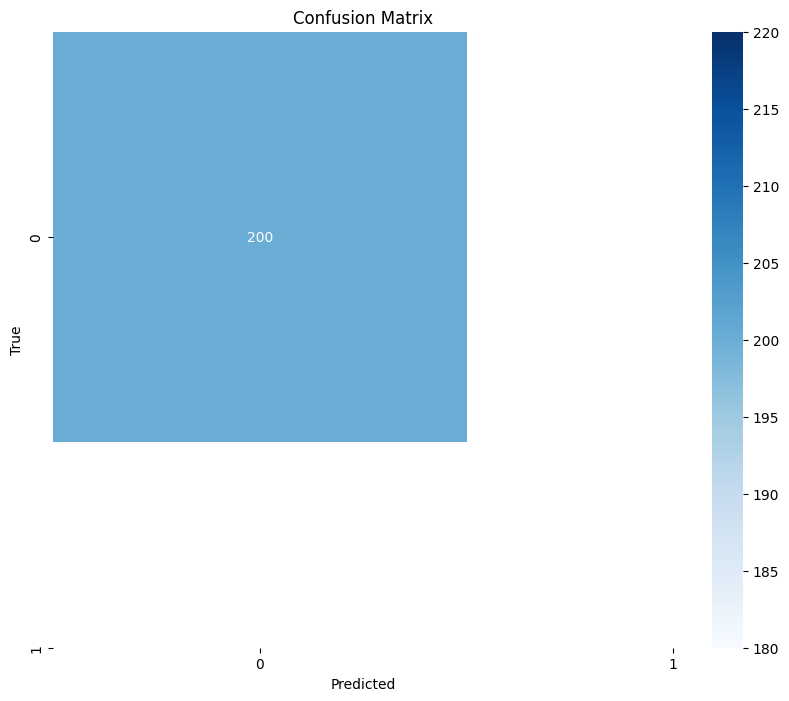

In [93]:
file_path = path_to_datasets + 'pos_frequencies_dataset.pkl'

with open(file_path, 'rb') as f:
    pos_frequencies_dataset = np.array(dill.load(f))

f1_metrics['pos_frequencies_dataset'] = train_and_evaluate_model(pos_frequencies_dataset, df['ttype'])

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9768 - loss: 0.5260 - precision_5: 0.0000e+00 - recall_5: 0.0000e+00
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.1098 - precision_5: 0.0000e+00 - recall_5: 0.0000e+00
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0047 - precision_5: 0.0000e+00 - recall_5: 0.0000e+00
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0011 - precision_5: 0.0000e+00 - recall_5: 0.0000e+00
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 6.8030e-04 - precision_5: 0.0000e+00 - recall_5: 0.0000e+00
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 4.6571e-04 - precision_5: 0.0000e+00 - recall_5: 0.0000e+00
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 2.5483e-04 - precision_5: 0.0000e+00 - recall_5: 0.0000e+00
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accur

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 4.5118e-05 - precision_5: 0.0000e+00 - recall_5: 0.0000e+00  


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                     │ (None, 128)                 │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,805 (206.27 KB)

 Trainable params: 17,601 (68.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 35,204 (137.52 KB)

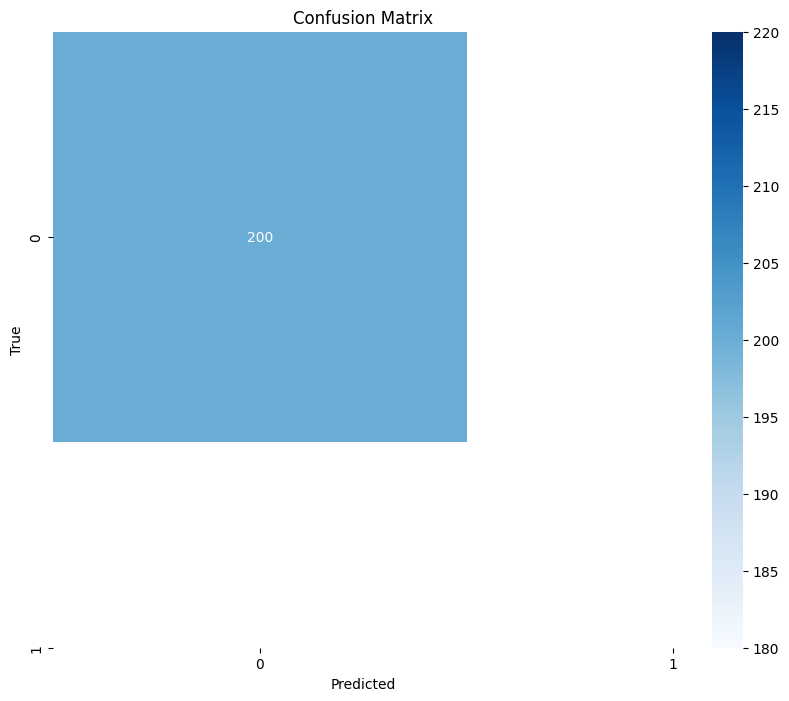

In [95]:
linis_crowd_dataset = np.array(pd.read_pickle(path_to_datasets + 'linis_crowd_dataset.pkl'))
f1_metrics['linis_crowd_dataset'] = train_and_evaluate_model(linis_crowd_dataset, df['ttype'])

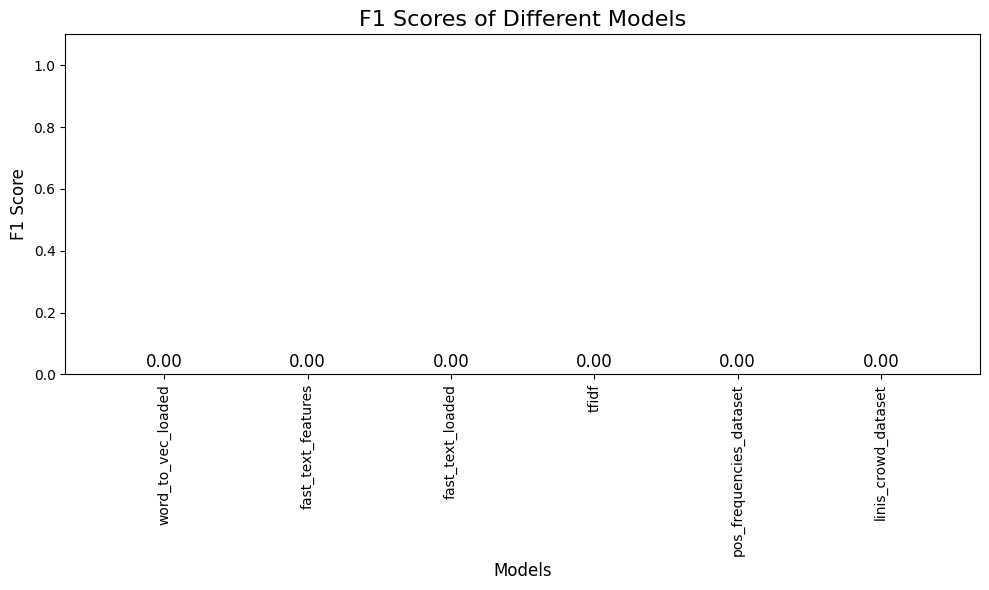

In [96]:
names = list(f1_metrics.keys())
values = list(f1_metrics.values())

plt.figure(figsize=(10, 6))
plt.bar(names, values, color='skyblue')

plt.xlabel('Models', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('F1 Scores of Different Models', fontsize=16)

for i, value in enumerate(values):
    plt.text(i, value + 0.01, f'{value:.2f}', ha='center', va='bottom', fontsize=12)

plt.xticks(rotation=90)

plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9238 - loss: 0.5962 - precision_6: 0.0000e+00 - recall_6: 0.0000e+00
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0910 - precision_6: 0.0000e+00 - recall_6: 0.0000e+00
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0012 - precision_6: 0.0000e+00 - recall_6: 0.0000e+00
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 3.7411e-04 - precision_6: 0.0000e+00 - recall_6: 0.0000e+00
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 2.5221e-04 - precision_6: 0.0000e+00 - recall_6: 0.0000e+00
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 1.9941e-04 - precision_6: 0.0000e+00 - recall_6: 0.0000e+00
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 2.0263e-04 - precision_6: 0.0000e+00 - recall_6: 0.0000e+00
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 8.9675e-05 - precision_6: 0.0000e+00 - recall_6: 0.0000e+00  


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                     │ (None, 128)                 │         128,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 434,501 (1.66 MB)

 Trainable params: 144,833 (565.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 289,668 (1.10 MB)

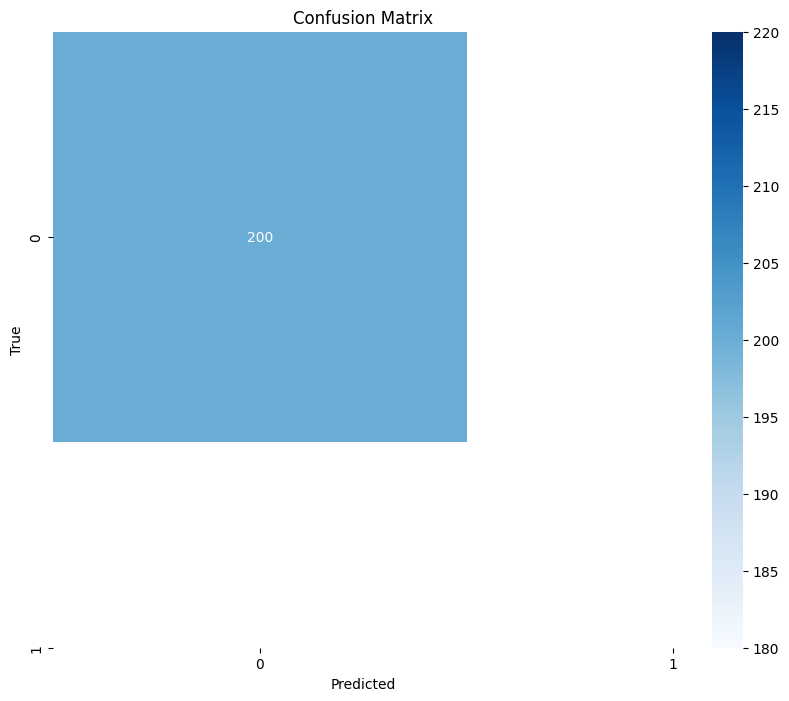

In [97]:
f1_metrics['tfidf'] = train_and_evaluate_model(tfidf, df['ttype'])